In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv("/content/02_nav_history_cleaned.csv")
perf = pd.read_csv("/content/07_scheme_performance_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239
3,2022-01-06,100016,515.7880
4,2022-01-07,100016,515.1639


In [2]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210


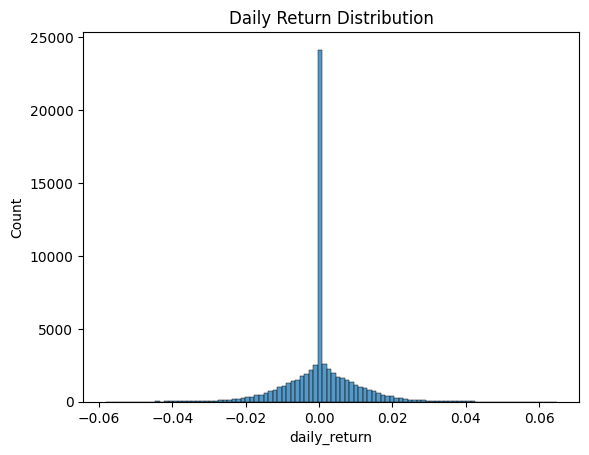

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100
)

plt.title("Daily Return Distribution")
plt.show()

CAGR

In [4]:
cagr_results = []

for code, grp in nav.groupby("amfi_code"):

    grp = grp.sort_values("date")

    start_nav = grp["nav"].iloc[0]
    end_nav = grp["nav"].iloc[-1]

    years = (
        grp["date"].max() -
        grp["date"].min()
    ).days / 365

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
    ) - 1

    cagr_results.append(
        [code, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


Sharpe Ratio
Risk Free Rate = 6.5%

In [5]:
RF = 0.065

sharpe_list = []

for code, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    sharpe = (
        (
            returns.mean()*252
            - RF
        )
        /
        (
            returns.std()
            * np.sqrt(252)
        )
    )

    sharpe_list.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.321019
1,100025,-1.039941
2,100033,0.808268
3,101206,0.717409
4,101207,0.052618


Sortino Ratio

In [6]:
sortino_list = []

for code, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    sortino = (
        (
            returns.mean()*252
            - RF
        )
        /
        downside_std
    )

    sortino_list.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "sortino_ratio"]
)

Maximum Drawdown

In [7]:
mdd_list = []

for code, grp in nav.groupby("amfi_code"):

    grp = grp.sort_values("date")

    running_max = grp["nav"].cummax()

    drawdown = (
        grp["nav"]
        /
        running_max
    ) - 1

    mdd = drawdown.min()

    mdd_list.append(
        [code, mdd]
    )

mdd_df = pd.DataFrame(
    mdd_list,
    columns=["amfi_code", "max_drawdown"]
)

Alpha & Beta

In [8]:
benchmark = pd.read_csv("/content/10_benchmark_indices.csv")

print(benchmark.columns.tolist())
print(benchmark.head())

['date', 'index_name', 'close_value']
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


Fund Scorecard

In [9]:
scorecard = perf.copy()

In [10]:
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        pct=True,
        ascending=False
    )
)

In [15]:
scorecard["amfi_code"] = scorecard["amfi_code"].astype(str)
sharpe_df["amfi_code"] = sharpe_df["amfi_code"].astype(str)
mdd_df["amfi_code"] = mdd_df["amfi_code"].astype(str)

# Rename columns in sharpe_df and mdd_df to avoid conflicts during merge
sharpe_df_renamed = sharpe_df.rename(columns={'sharpe_ratio': 'calculated_sharpe_ratio'})
mdd_df_renamed = mdd_df.rename(columns={'max_drawdown': 'calculated_max_drawdown'})

scorecard = scorecard.merge(sharpe_df_renamed, on="amfi_code", how="left")
scorecard = scorecard.merge(mdd_df_renamed, on="amfi_code", how="left")

scorecard["sharpe_rank"] = (
    scorecard["calculated_sharpe_ratio"]
    .rank(pct=True)
)

scorecard["mdd_rank"] = (
    scorecard["calculated_max_drawdown"]
    .rank(pct=True, ascending=False)
)

# Now that alpha_rank is available, the fund_score can be calculated.
scorecard["fund_score"] = (
    scorecard["return_rank"] * 30
    + scorecard["sharpe_rank"] * 25
    + scorecard["alpha_rank"] * 20
    + scorecard["expense_rank"] * 15
    + scorecard["mdd_rank"] * 10
)

In [16]:
benchmark = pd.read_csv("/content/10_benchmark_indices.csv")

print(benchmark.columns.tolist())
print(benchmark.head())

['date', 'index_name', 'close_value']
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15


In [17]:
benchmark = pd.read_csv("/content/10_benchmark_indices.csv")

benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [18]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100[
    ["date", "benchmark_return"]
]

nifty100.head()

,date,benchmark_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150


In [19]:
from scipy.stats import linregress

alpha_beta_list = []

for code, grp in nav.groupby("amfi_code"):

    temp = grp.merge(
        nifty100,
        on="date",
        how="inner"
    )

    temp = temp.dropna(
        subset=[
            "daily_return",
            "benchmark_return"
        ]
    )

    if len(temp) < 30:
        continue

    regression = linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )

    beta = regression.slope

    alpha = regression.intercept * 252

    alpha_beta_list.append(
        [code, alpha, beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta_list,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [20]:
alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [23]:
scorecard["amfi_code"] = (
    scorecard["amfi_code"]
    .astype(str)
)

alpha_beta_df["amfi_code"] = (
    alpha_beta_df["amfi_code"]
    .astype(str)
)

# Rename alpha and beta columns in alpha_beta_df to avoid conflicts with existing columns in scorecard
alpha_beta_df_renamed = alpha_beta_df.rename(columns={'alpha': 'calculated_alpha', 'beta': 'calculated_beta'})

scorecard = scorecard.merge(
    alpha_beta_df_renamed,
    on="amfi_code",
    how="left"
)

In [24]:
scorecard["alpha_rank"] = (
    scorecard["calculated_alpha"]
    .rank(pct=True)
)

In [25]:
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True)
)

In [26]:
scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(
        pct=True,
        ascending=False
    )
)

In [27]:
scorecard["fund_score"] = (
      scorecard["return_rank"] * 30
    + scorecard["sharpe_rank"] * 25
    + scorecard["alpha_rank"] * 20
    + scorecard["expense_rank"] * 15
    + scorecard["mdd_rank"] * 10
)

In [28]:
scorecard["fund_score"] = (
    scorecard["fund_score"] /
    scorecard["fund_score"].max()
) * 100

In [29]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard[
    [
        "scheme_name",
        "fund_score"
    ]
].head(10)

,scheme_name,fund_score
2,SBI Small Cap Fund - Regular Plan - Growth,100.000000
12,ICICI Pru Midcap Fund - Regular - Growth,98.660714
39,DSP Small Cap Fund - Regular - Growth,93.526786
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,90.476190
22,Kotak Flexicap Fund - Regular - Growth,89.583333
26,Axis Midcap Fund - Regular - Growth,85.119048
38,DSP Midcap Fund - Regular - Growth,82.142857
34,Mirae Asset Large Cap Fund - Regular - Growth,81.845238
36,Mirae Asset Tax Saver Fund - Regular - Growth,74.627976
15,Nippon India Large Cap Fund - Regular - Growth,74.479167


In [30]:
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [31]:
top5 = scorecard.head(5)[
    "amfi_code"
].tolist()

In [32]:
import plotly.express as px

chart_data = nav[
    nav["amfi_code"].astype(str)
    .isin(top5)
]

fig = px.line(
    chart_data,
    x="date",
    y="nav",
    color="amfi_code",
    title="Top 5 Funds NAV Comparison"
)

fig.show()

In [33]:
tracking_errors = []

for code in top5:

    fund = nav[
        nav["amfi_code"].astype(str)
        == str(code)
    ]

    temp = fund.merge(
        nifty100,
        on="date"
    )

    temp = temp.dropna()

    te = (
        (
            temp["daily_return"]
            -
            temp["benchmark_return"]
        )
        .std()
        *
        np.sqrt(252)
    )

    tracking_errors.append(
        [code, te]
    )

tracking_error_df = pd.DataFrame(
    tracking_errors,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df

,amfi_code,tracking_error
0,119598,0.283881
1,120505,0.231968
2,149324,0.279170
3,100033,0.228699
4,120843,0.206425
